In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sae_rfs = np.load('/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_sae_final_rfs.npy', allow_pickle=True)
pca_ae_rfs = np.load('/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_pca-ae_final_rfs.npy', allow_pickle=True)
dev_ae_rfs = np.load('/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_dev-ae_final_rfs.npy', allow_pickle=True)

In [3]:
print(sae_rfs.shape)
print(pca_ae_rfs.shape)
print(dev_ae_rfs.shape)

(10, 128, 3, 32, 32)
(10, 128, 3, 32, 32)
(10, 128, 3, 32, 32)


In [4]:
sae_dim = np.load('/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_sae_dimensionality.npy', allow_pickle=True)
pca_ae_dim = np.load('/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_pca-ae_dimensionality.npy', allow_pickle=True)
dev_ae_dim = np.load('/home/david/Documents/UNI_LOCAL/developing-autoencoders/paper_results/cifar_dev-ae_dimensionality.npy', allow_pickle=True)

In [5]:
print(sae_dim.shape)
print(pca_ae_dim.shape)
print(dev_ae_dim.shape)

(10, 60)
(10, 60)
(3, 60)


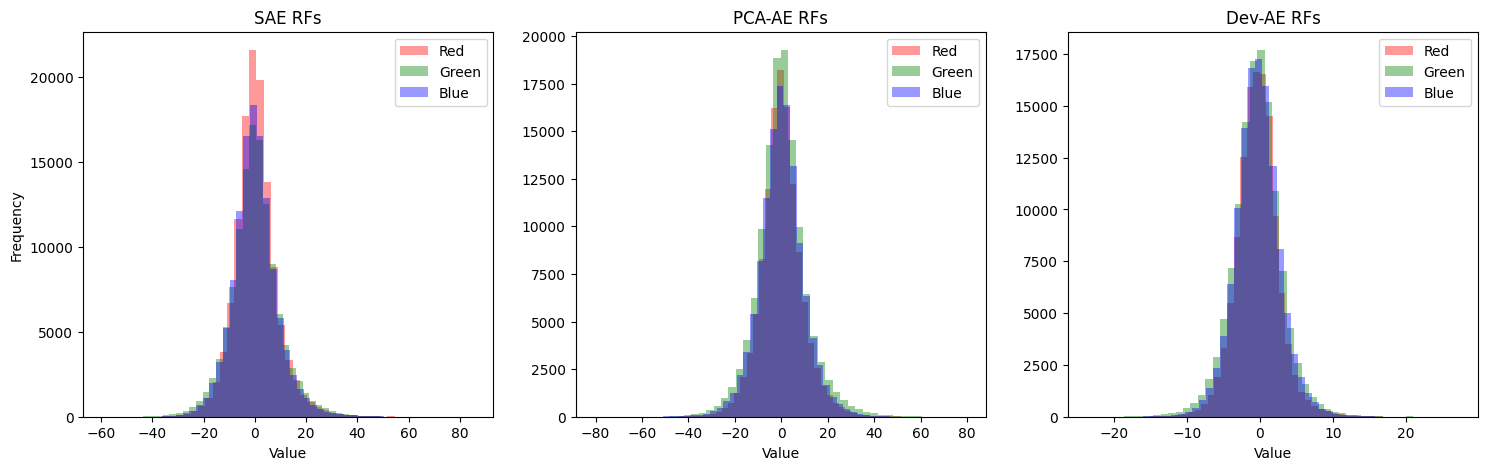

In [6]:
plt.figure(figsize=(18, 5))

# Plot for SAE
plt.subplot(1, 3, 1)
plt.hist(sae_rfs[..., 0].flatten(), bins=50, alpha=0.4, color='red', label='Red')
plt.hist(sae_rfs[..., 1].flatten(), bins=50, alpha=0.4, color='green', label='Green')
plt.hist(sae_rfs[..., 2].flatten(), bins=50, alpha=0.4, color='blue', label='Blue')
plt.title('SAE RFs')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

# Plot for PCA-AE
plt.subplot(1, 3, 2)
plt.hist(pca_ae_rfs[..., 0].flatten(), bins=50, alpha=0.4, color='red', label='Red')
plt.hist(pca_ae_rfs[..., 1].flatten(), bins=50, alpha=0.4, color='green', label='Green')
plt.hist(pca_ae_rfs[..., 2].flatten(), bins=50, alpha=0.4, color='blue', label='Blue')
plt.title('PCA-AE RFs')
plt.xlabel('Value')
plt.legend()

# Plot for Dev-AE
plt.subplot(1, 3, 3)
plt.hist(dev_ae_rfs[..., 0].flatten(), bins=50, alpha=0.4, color='red', label='Red')
plt.hist(dev_ae_rfs[..., 1].flatten(), bins=50, alpha=0.4, color='green', label='Green')
plt.hist(dev_ae_rfs[..., 2].flatten(), bins=50, alpha=0.4, color='blue', label='Blue')
plt.title('Dev-AE RFs')
plt.xlabel('Value')
plt.legend()

plt.show()

In [7]:
from scipy.spatial.distance import jensenshannon

def calculate_color_divergence(rfs, bins=50):
    """Calculates the average pairwise Jensen-Shannon divergence between color channels."""
    
    # Define common bins for all channels based on the overall data range
    min_val, max_val = rfs.min(), rfs.max()
    bin_edges = np.linspace(min_val, max_val, bins + 1)
    
    # Get histograms for each channel
    p_r, _ = np.histogram(rfs[..., 0].flatten(), bins=bin_edges, density=True)
    p_g, _ = np.histogram(rfs[..., 1].flatten(), bins=bin_edges, density=True)
    p_b, _ = np.histogram(rfs[..., 2].flatten(), bins=bin_edges, density=True)
    
    # Normalize histograms to be probability distributions
    p_r /= p_r.sum()
    p_g /= p_g.sum()
    p_b /= p_b.sum()
    
    # Calculate pairwise JS divergence (the square of the metric)
    js_rg = jensenshannon(p_r, p_g)**2
    js_rb = jensenshannon(p_r, p_b)**2
    js_gb = jensenshannon(p_g, p_b)**2
    
    # Return the average divergence
    return (js_rg + js_rb + js_gb) / 3

# Calculate divergence for each model
sae_divergence = calculate_color_divergence(sae_rfs)
pca_ae_divergence = calculate_color_divergence(pca_ae_rfs)
dev_ae_divergence = calculate_color_divergence(dev_ae_rfs)

print(f"SAE Avg. Color Divergence: {sae_divergence:.6f}")
print(f"PCA-AE Avg. Color Divergence: {pca_ae_divergence:.6f}")
print(f"Dev-AE Avg. Color Divergence: {dev_ae_divergence:.6f}")

SAE Avg. Color Divergence: 0.002463
PCA-AE Avg. Color Divergence: 0.002527
Dev-AE Avg. Color Divergence: 0.002246


In [8]:
from scipy.stats import entropy

def calculate_kl_divergence(rfs, bins=50):
    """Calculates the average symmetric KL divergence between color channels."""
    
    # Define common bins for all channels based on the overall data range
    min_val, max_val = rfs.min(), rfs.max()
    bin_edges = np.linspace(min_val, max_val, bins + 1)
    
    # Get histograms for each channel
    p_r, _ = np.histogram(rfs[..., 0].flatten(), bins=bin_edges, density=True)
    p_g, _ = np.histogram(rfs[..., 1].flatten(), bins=bin_edges, density=True)
    p_b, _ = np.histogram(rfs[..., 2].flatten(), bins=bin_edges, density=True)
    
    # Add a small epsilon to avoid division by zero in KL divergence
    epsilon = 1e-10
    p_r += epsilon
    p_g += epsilon
    p_b += epsilon

    # Normalize histograms to be probability distributions
    p_r /= p_r.sum()
    p_g /= p_g.sum()
    p_b /= p_b.sum()
    
    # Calculate symmetric KL divergence for each pair
    kl_rg = (entropy(p_r, p_g) + entropy(p_g, p_r)) / 2
    kl_rb = (entropy(p_r, p_b) + entropy(p_b, p_r)) / 2
    kl_gb = (entropy(p_g, p_b) + entropy(p_b, p_g)) / 2
    
    # Return the average divergence
    return (kl_rg + kl_rb + kl_gb) / 3

# Calculate divergence for each model
sae_kl_divergence = calculate_kl_divergence(sae_rfs)
pca_ae_kl_divergence = calculate_kl_divergence(pca_ae_rfs)
dev_ae_kl_divergence = calculate_kl_divergence(dev_ae_rfs)

print(f"SAE Avg. Symmetric KL Divergence: {sae_kl_divergence:.6f}")
print(f"PCA-AE Avg. Symmetric KL Divergence: {pca_ae_kl_divergence:.6f}")
print(f"Dev-AE Avg. Symmetric KL Divergence: {dev_ae_kl_divergence:.6f}")

SAE Avg. Symmetric KL Divergence: 0.010263
PCA-AE Avg. Symmetric KL Divergence: 0.011776
Dev-AE Avg. Symmetric KL Divergence: 0.009339
